# CN4 - Computation and Plot of ST statistics (without Masks)

In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])


from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
DataClass = STL_2D_FFT_Torch
WO = WaveletOperator2D_FFT_torch
WaveletOperatorClass = WaveletOperator2D_FFT_torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset dirctory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

shape data = (256, 256)
shape data_full = (20, 256, 256)


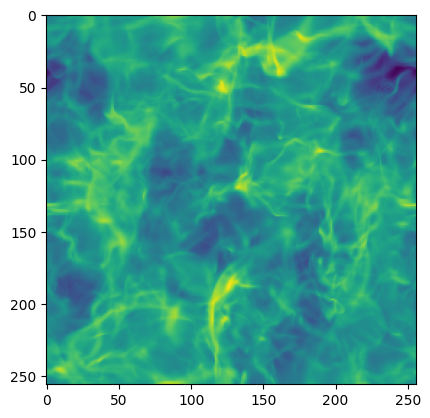

In [3]:
# Load some data
data_full = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")
data = data_full[0]
print("shape data = " + str(data.shape))
print("shape data_full = " + str(data_full.shape))
plt.imshow(data)

In [4]:
# Create STL data object and get ST operator
stl_data = DataClass(data, pbc=True)
# stl_data.set_fourier_status(target_fourier_status=True, inplace=True)
stl_op = stl_data.get_ST_op(J=4, L=8, WType="Gaussian")

In [5]:
stl_stats = stl_op.apply(stl_data, has_fewer_convolutions=True)

In [6]:
# Check all attributes of the ST operator instance
print("For stl_op:", "\n")
print("DT = " + str(stl_op.DT))
print()
print("J = " + str(stl_op.J))
print("L = " + str(stl_op.L))
print("WType = " + str(stl_op.WType))
print()
print("SC = " + str(stl_op.SC))
print()
print("norm = " + str(stl_op.norm))
print("S2_ref_sqrt_chan_diag = " + str(stl_op.S2_ref_sqrt_chan_diag))
print("iso = " + str(stl_op.iso))
print("angular_ft = " + str(stl_op.angular_ft))
print("scale_ft = " + str(stl_op.scale_ft))
print("flatten = " + str(stl_op.flatten))
print("mask_st = " + str(stl_op.mask_st))

For stl_op: 

DT = Planar2D_FFT_torch

J = 4
L = 8
WType = Gaussian

SC = ScatCov

norm = store_ref
S2_ref_sqrt_chan_diag = tensor([[[[0.0075, 0.0067, 0.0061, 0.0066, 0.0073, 0.0070, 0.0068, 0.0073],
          [0.0160, 0.0147, 0.0144, 0.0154, 0.0163, 0.0160, 0.0158, 0.0163],
          [0.0253, 0.0239, 0.0251, 0.0264, 0.0269, 0.0258, 0.0250, 0.0259],
          [0.0367, 0.0341, 0.0335, 0.0315, 0.0324, 0.0312, 0.0318, 0.0361]]]],
       dtype=torch.float64)
iso = False
angular_ft = False
scale_ft = False
flatten = False
mask_st = None


In [7]:
data = data_full[:, None, ...]
stl_data = DataClass(data, pbc=True)
stl_data.set_fourier_status(target_fourier_status=True, inplace=True)
stl_op = stl_data.get_ST_op(J=4, L=2)
stl_stats = stl_op.apply(stl_data)

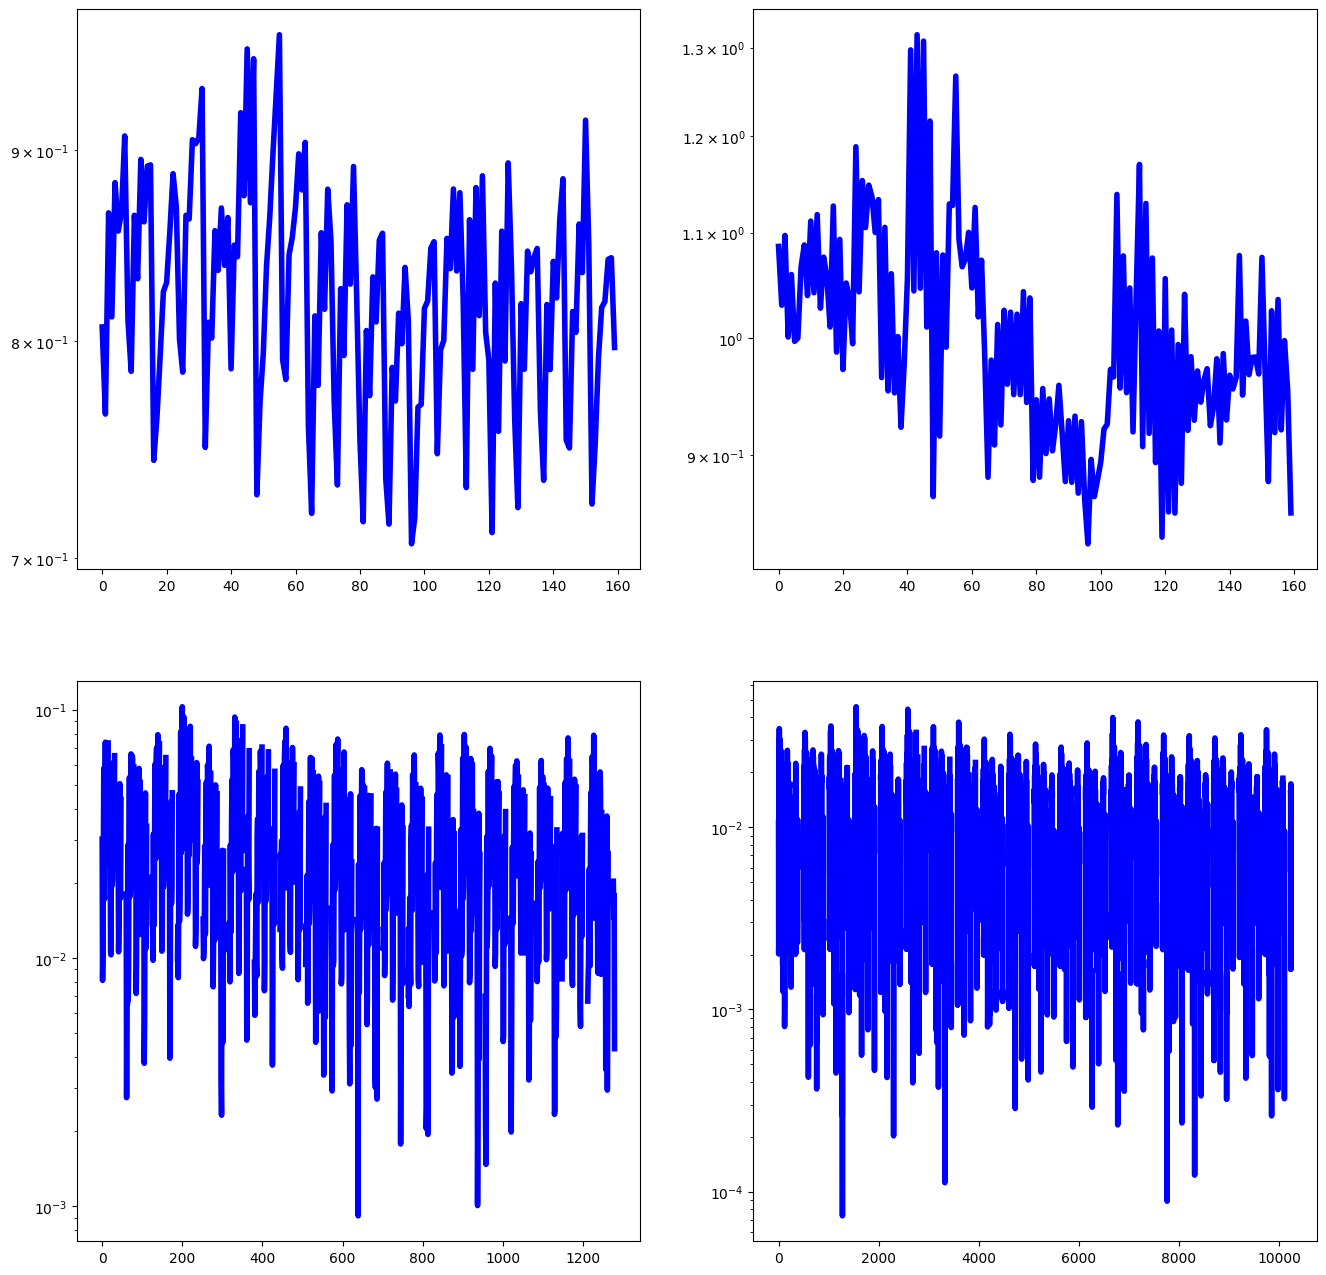

In [8]:
plt.figure(figsize=(16,16))
plt.subplot(2,2,1)
plt.plot(stl_stats.S1.cpu().numpy().flatten(),color='b',lw=4)
plt.yscale('log')
plt.subplot(2,2,2)
plt.plot(stl_stats.S2.cpu().numpy().flatten(),color='b',lw=4)
plt.yscale('log')


plt.subplot(2,2,3)
plt.plot(stl_stats.S3.abs().cpu().numpy().flatten(),color='b',lw=4)
plt.yscale('log')
plt.subplot(2,2,4)
plt.plot(stl_stats.S4.cpu().abs().numpy().flatten(),color='b',lw=4)
plt.yscale('log')

#### PBC = False

In [9]:
stl_data = DataClass(data, pbc=False)

st_op = stl_data.get_ST_op(WType="Bump-Steerable", get_crop_border_size_method=WO._get_crop_border_size_fully_flexible)
st_data = st_op.apply(stl_data, norm='vanilla')

Warning! Data with shape (16, 16) too small to be cropped with border 9. Using border=7 instead.


Warning! Data with shape (16, 16) too small to be cropped with border 8. Using border=7 instead.
Warning! Data with shape (256, 256) too small to be cropped with border 190. Using border=127 instead.
Warning! Data with shape (256, 256) too small to be cropped with border 190. Using border=127 instead.


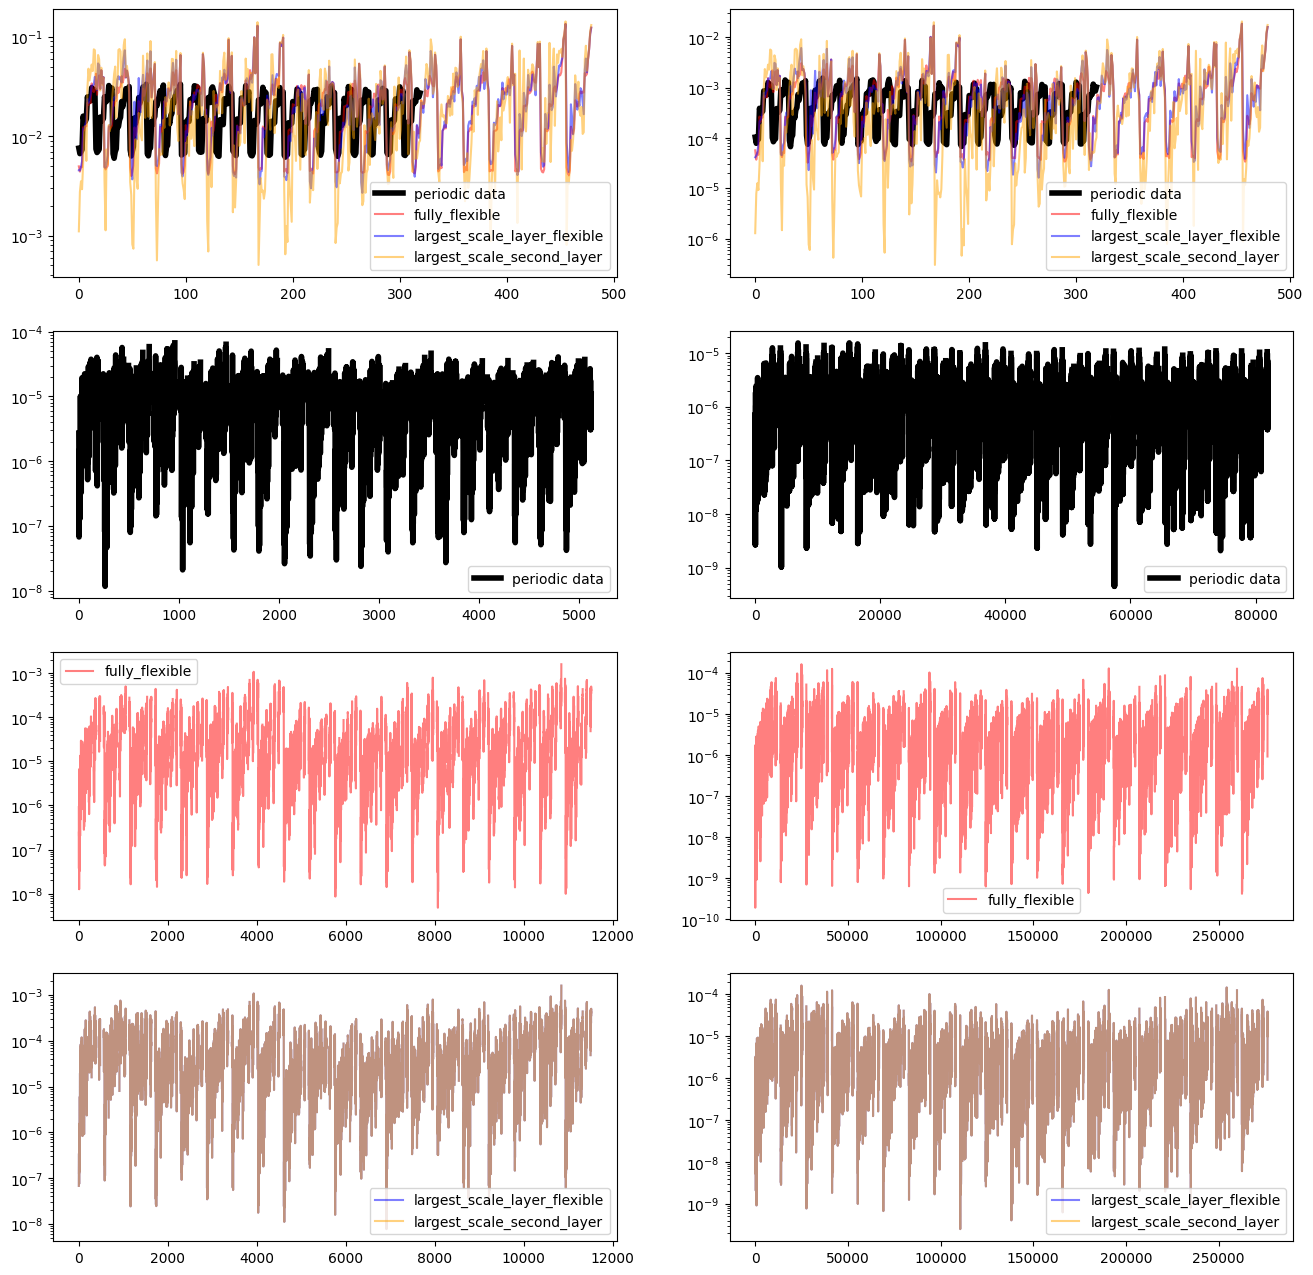

In [10]:
stl_data = DataClass(data, pbc=True)
stl_data_npbc = DataClass(data[:128,:128], pbc=False)

st_op = stl_data.get_ST_op(J = 4)
st_data = st_op.apply(stl_data, norm='vanilla')

plt.figure(figsize=(16,16))

plt.subplot(4,2,1)
plt.plot(st_data.S1.cpu().numpy().flatten(), color='black', lw=4, label='periodic data')

plt.subplot(4,2,2)
plt.plot(st_data.S2.cpu().numpy().flatten(), color='black', lw=4, label='periodic data')

plt.subplot(4,2,3)
plt.plot(st_data.S3.abs().cpu().numpy().flatten(), color='black', lw=4, label='periodic data')
plt.yscale('log')
plt.legend()

plt.subplot(4,2,4)
plt.plot(st_data.S4.cpu().abs().numpy().flatten(), color='black', lw=4, label='periodic data')
plt.yscale('log')
plt.legend()

colors = {'fully_flexible': 'red',
          'largest_scale_layer_flexible': 'blue',
          'largest_scale_second_layer': 'orange'}

for method_name, get_crop_border_size_method in zip(['fully_flexible', 
                                                     'largest_scale_layer_flexible', 
                                                     'largest_scale_second_layer'],
                                                    [WO._get_crop_border_size_fully_flexible,
                                                     WO._get_crop_border_size_largest_scale_layer_flexible,
                                                     WO._get_crop_border_size_largest_scale_second_layer]):
    
    st_op_npbc = stl_data_npbc.get_ST_op( 
                    WType="Gaussian",
                    get_crop_border_size_method=get_crop_border_size_method)
    st_data_npbc = st_op_npbc.apply(stl_data_npbc, norm='vanilla')

    plt.subplot(4,2,1)
    plt.plot(st_data_npbc.S1.cpu().numpy().flatten(),color=colors[method_name], label=method_name, alpha=0.5)
    plt.yscale('log')
    plt.legend()

    plt.subplot(4,2,2)
    plt.plot(st_data_npbc.S2.cpu().numpy().flatten(),color=colors[method_name], label=method_name, alpha=0.5)
    plt.yscale('log')
    plt.legend()

    plt.subplot(4,2,7 if method_name != 'fully_flexible' else 5)
    plt.plot(st_data_npbc.S3.abs().cpu().numpy().flatten(),color=colors[method_name], label=method_name, alpha=0.5)
    plt.yscale('log')
    plt.legend()

    plt.subplot(4,2,8 if method_name != 'fully_flexible' else 6)
    plt.plot(st_data_npbc.S4.cpu().abs().numpy().flatten(),color=colors[method_name], label=method_name, alpha=0.5)
    plt.yscale('log')
    plt.legend()

plt.show()